# Does Quantization Break Physical Reasoning? A Live Demo

This notebook runs **one real question, on one real image, through the same model
at four different quantization levels** (FP16, INT8, INT4, INT3), live, so you can
see the degradation happen rather than just read about it in a table.

The example below was picked because it shows the exact pattern found across the
full 100-item study: the answer is correct at FP16, INT8, and INT4 — then **flips
to wrong specifically at INT3**, matching the sharp INT4→INT3 cliff seen in the
`spatial_relation` sub-skill overall (75% → 55% accuracy across the full 20-item set).

Everything below actually runs `llama-mtmd-cli` on your machine — nothing is
pre-canned. Expect ~1-2 minutes total (four inference calls, ~15-40 sec each).

In [1]:
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path(r"E:\quantization-world-model")
LLAMA_CLI = ROOT / "llama.cpp" / "build" / "bin" / "llama-mtmd-cli.exe"
MMPROJ = ROOT / "models" / "fp16" / "qwen2vl-2b-mmproj-f16.gguf"

MODELS = {
    "FP16": ROOT / "models" / "fp16"  / "qwen2vl-2b-fp16.gguf",
    "INT8": ROOT / "models" / "int8"  / "qwen2vl-2b-int8.gguf",
    "INT4": ROOT / "models" / "int4"  / "qwen2vl-2b-int4.gguf",
    "INT3": ROOT / "models" / "int3"  / "qwen2vl-2b-int3.gguf",
}

IMAGE_PATH = ROOT / "data" / "processed" / "images" / "spatial_003.jpg"
QUESTION = "What is the material of the object to collide with the green cylinder?"
CHOICES = ["A. metal", "B. rubber"]
CORRECT_ANSWER = "A"

print("Model files present:", {k: v.exists() for k, v in MODELS.items()})

Model files present: {'FP16': True, 'INT8': True, 'INT4': True, 'INT3': True}


## The item

A static frame from a real CLEVRER physics scene, sourced with real ground truth (see `docs/ATTRIBUTION_LOG.md`). The question requires reasoning about a collision event — which object the green cylinder hits — from a single frame.

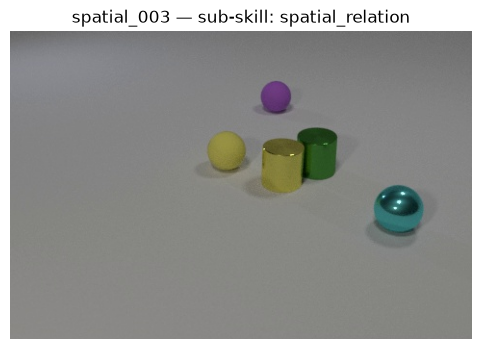

Question: What is the material of the object to collide with the green cylinder?
Choices:  A. metal, B. rubber
Ground-truth answer: A (A. metal)


In [2]:
img = Image.open(IMAGE_PATH)
plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis("off")
plt.title("spatial_003 — sub-skill: spatial_relation")
plt.show()

print("Question:", QUESTION)
print("Choices: ", ", ".join(CHOICES))
print("Ground-truth answer:", CORRECT_ANSWER, f"({[c for c in CHOICES if c.startswith(CORRECT_ANSWER)][0]})")

## Running live inference at each precision level

Same image, same question, same prompt template — only the model weights change.

In [3]:
def build_prompt():
    choices_block = "\n".join(CHOICES)
    return f"{QUESTION}\n{choices_block}\nAnswer with only the letter of the correct choice."


def run_one(model_path):
    cmd = [
        str(LLAMA_CLI),
        "-m", str(model_path),
        "--mmproj", str(MMPROJ),
        "--image", str(IMAGE_PATH),
        "-p", build_prompt(),
        "-n", "64",
        "--temp", "0",
    ]
    start = time.time()
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=600)
    elapsed = time.time() - start
    return result.stdout.strip(), elapsed


results = {}
for precision, model_path in MODELS.items():
    print(f"Running {precision}...", end=" ", flush=True)
    output, elapsed = run_one(model_path)
    results[precision] = {"raw_output": output, "latency_sec": round(elapsed, 1)}
    print(f"-> {output!r}  ({elapsed:.1f}s)")

Running FP16... 

-> 'A'  (41.0s)
Running INT8... 

-> 'A'  (26.2s)
Running INT4... 

-> 'A'  (15.5s)
Running INT3... 

-> 'B'  (16.2s)


## Side-by-side comparison

In [4]:
import re

print(f"{'Precision':<8} {'Answer':<8} {'Correct?':<10} {'Latency':<10}")
print("-" * 40)
for precision, r in results.items():
    match = re.search(r"\b([A-D])\b", (r["raw_output"] or "")[:50])
    parsed = match.group(1) if match else None
    correct = "YES" if parsed == CORRECT_ANSWER else "no" if parsed else "?"
    flag = "  <-- flips here" if precision == "INT3" and parsed != CORRECT_ANSWER else ""
    print(f"{precision:<8} {str(parsed):<8} {correct:<10} {r['latency_sec']}s{flag}")

Precision Answer   Correct?   Latency   
----------------------------------------
FP16     A        YES        41.0s
INT8     A        YES        26.2s
INT4     A        YES        15.5s
INT3     B        no         16.2s  <-- flips here


## Does this hold at scale?

This single item is illustrative, not proof on its own — one flipped answer could be
noise. The full study ran this same comparison across **100 items spanning 5
sub-skills**, and the pattern above (flat through INT8/INT4, sharp drop at INT3)
is exactly what `spatial_relation` shows in aggregate:

                      fp16  int8  int4  int3
subskill                                    
spatial_relation      0.70  0.70  0.75  0.55
causal_reasoning      0.65  0.65  0.60  0.50
temporal_consistency  0.80  0.80  0.80  0.75


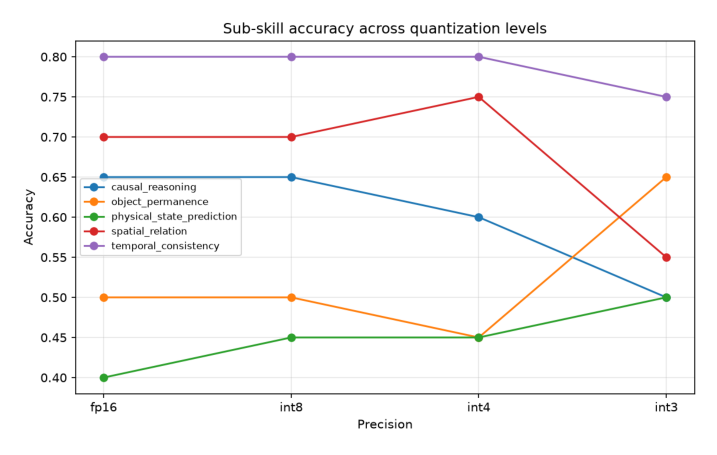

In [5]:
import pandas as pd

acc = pd.read_csv(ROOT / "results" / "accuracy_table.csv", index_col=0)
print(acc.loc[["spatial_relation", "causal_reasoning", "temporal_consistency"]])

img2 = Image.open(ROOT / "results" / "degradation_curves.png")
plt.figure(figsize=(9, 6))
plt.imshow(img2)
plt.axis("off")
plt.show()

## Caveat

This notebook demonstrates the finding, it doesn't independently establish it —
that's what the full 100-item sweep and the statistical discussion in
`docs/paper_draft.md` are for. With n=20 items per sub-skill, individual
differences carry a wide confidence interval (~±22 percentage points at p≈0.5);
the value of this notebook is making the pattern *tangible*, not proving it on its
own. See `docs/paper_draft.md` §IV for the full result and its honest statistical
caveat.